<a href="https://colab.research.google.com/github/ElderGut/Actividad5/blob/main/cuatri_4_act_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn scipy

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [ ]:


data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Dimensiones: (569, 31)
Valores nulos: 0
Duplicados: 0

Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64


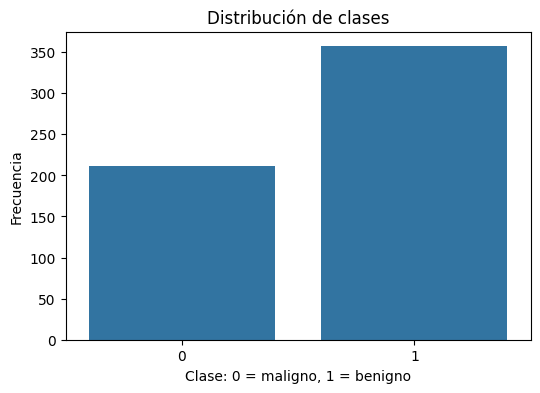

In [ ]:


print("Dimensiones:", df.shape)
print("Valores nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())
print("\nDistribución de clases:")
print(df["target"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Distribución de clases")
plt.xlabel("Clase: 0 = maligno, 1 = benigno")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:


X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (455, 30)
Test: (114, 30)


In [ ]:


models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.1,
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        random_state=42
    )
}

In [ ]:
#celda 7

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy Baseline,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistic Regression,0.973684,0.972603,0.986111,0.979310,0.995701
2,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993056


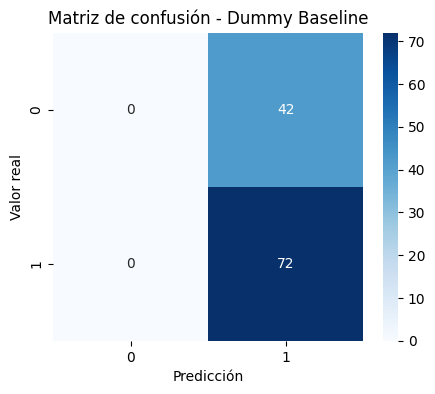

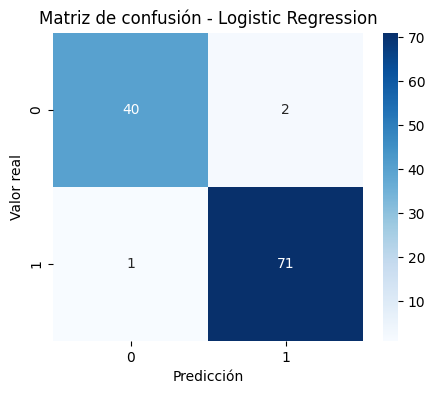

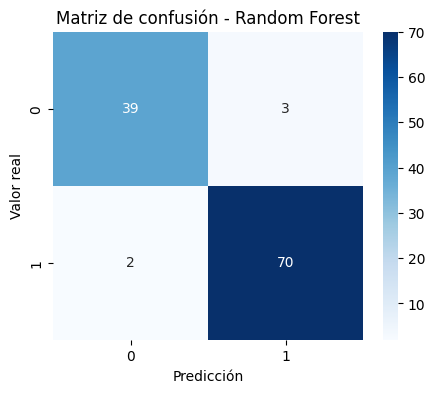

In [ ]:
#celda 8

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusión - {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

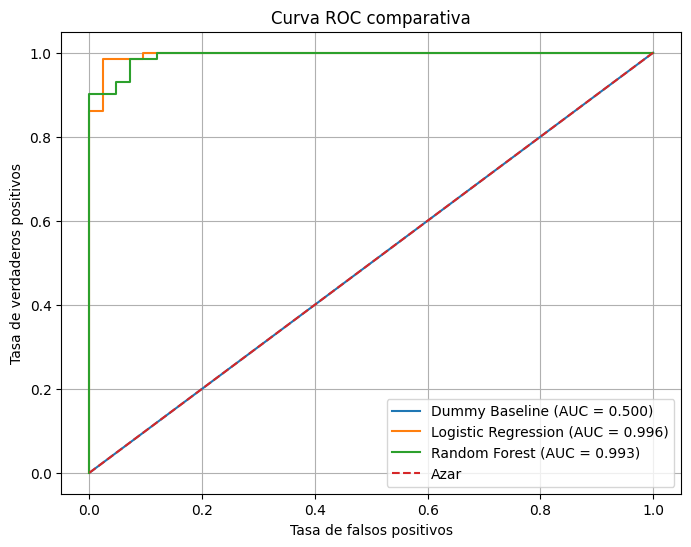

In [ ]:
#celda 9

plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.predict(X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.title("Curva ROC comparativa")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid()
plt.show()

In [ ]:
#celda 10

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Modelo": name,
        "F1 promedio CV": scores.mean(),
        "Desviación estándar": scores.std(),
        "Scores": scores
    })

cv_df = pd.DataFrame(cv_results)
cv_df[["Modelo", "F1 promedio CV", "Desviación estándar"]]

,Modelo,F1 promedio CV,Desviación estándar
0,Dummy Baseline,0.771052,0.002983
1,Logistic Regression,0.979493,0.012723
2,Random Forest,0.963708,0.007965


In [ ]:
#celda 11

baseline_f1 = cv_df.loc[cv_df["Modelo"] == "Dummy Baseline", "F1 promedio CV"].values[0]

comparison_baseline = cv_df.copy()
comparison_baseline["Mejora vs Baseline"] = comparison_baseline["F1 promedio CV"] - baseline_f1

comparison_baseline[["Modelo", "F1 promedio CV", "Mejora vs Baseline"]]

,Modelo,F1 promedio CV,Mejora vs Baseline
0,Dummy Baseline,0.771052,0.000000
1,Logistic Regression,0.979493,0.208441
2,Random Forest,0.963708,0.192656


In [ ]:
#celda 12

log_scores = cv_df.loc[cv_df["Modelo"] == "Logistic Regression", "Scores"].values[0]
rf_scores = cv_df.loc[cv_df["Modelo"] == "Random Forest", "Scores"].values[0]

t_stat, p_value = ttest_rel(log_scores, rf_scores)

print("Prueba t pareada: Logistic Regression vs Random Forest")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Existe diferencia estadísticamente significativa entre los modelos.")
else:
    print("No se encontró diferencia estadísticamente significativa entre los modelos.")

Prueba t pareada: Logistic Regression vs Random Forest
t-statistic: 2.7195535382418083
p-value: 0.05301129851894571
No se encontró diferencia estadísticamente significativa entre los modelos.


In [ ]:
#celda 13

best_model = models["Logistic Regression"]

y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Umbral": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Umbral,Accuracy,Precision,Recall,F1
0,0.10,0.947368,0.923077,1.000000,0.960000
1,0.15,0.947368,0.923077,1.000000,0.960000
2,0.20,0.956140,0.935065,1.000000,0.966443
3,0.25,0.964912,0.947368,1.000000,0.972973
4,0.30,0.964912,0.947368,1.000000,0.972973
5,0.35,0.964912,0.947368,1.000000,0.972973
6,0.40,0.964912,0.959459,0.986111,0.972603
7,0.45,0.973684,0.972603,0.986111,0.979310
8,0.50,0.973684,0.972603,0.986111,0.979310
9,0.55,0.982456,0.986111,0.986111,0.986111


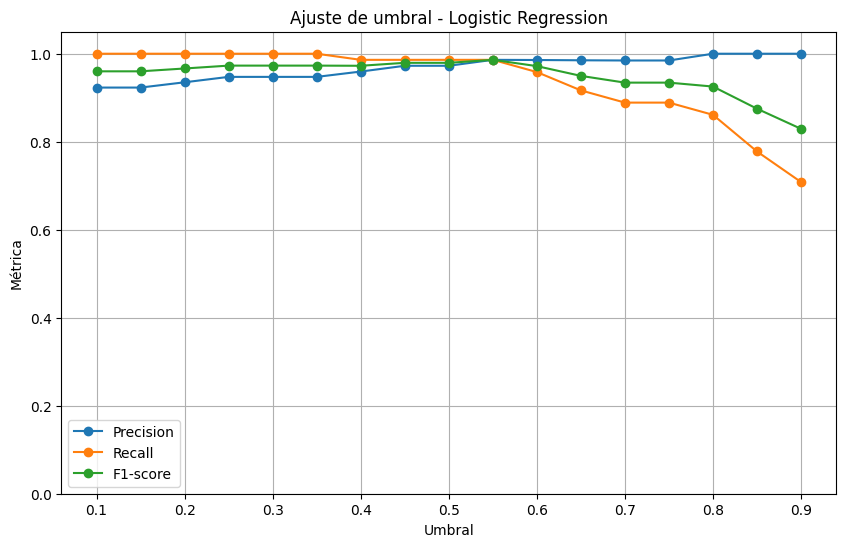

In [ ]:
#celda 14

plt.figure(figsize=(10,6))

plt.plot(threshold_df["Umbral"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Umbral"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Umbral"], threshold_df["F1"], marker="o", label="F1-score")

plt.title("Ajuste de umbral - Logistic Regression")
plt.xlabel("Umbral")
plt.ylabel("Métrica")
plt.ylim(0, 1.05)
plt.grid()
plt.legend()
plt.show()

In [ ]:
#celda 15
best_threshold_row = threshold_df.sort_values(by="F1", ascending=False).iloc[0]

best_threshold_row

,9
Umbral,0.550000
Accuracy,0.982456
Precision,0.986111
Recall,0.986111
F1,0.986111


In [ ]:
#celda 16

ab_test = pd.DataFrame({
    "Grupo": ["A", "B"],
    "Modelo": ["Logistic Regression", "Random Forest"],
    "F1 CV Promedio": [
        cv_df.loc[cv_df["Modelo"] == "Logistic Regression", "F1 promedio CV"].values[0],
        cv_df.loc[cv_df["Modelo"] == "Random Forest", "F1 promedio CV"].values[0]
    ],
    "ROC-AUC Test": [
        results_df.loc[results_df["Modelo"] == "Logistic Regression", "ROC-AUC"].values[0],
        results_df.loc[results_df["Modelo"] == "Random Forest", "ROC-AUC"].values[0]
    ]
})

ab_test

,Grupo,Modelo,F1 CV Promedio,ROC-AUC Test
0,A,Logistic Regression,0.979493,0.995701
1,B,Random Forest,0.963708,0.993056


<Figure size 1000x600 with 0 Axes>

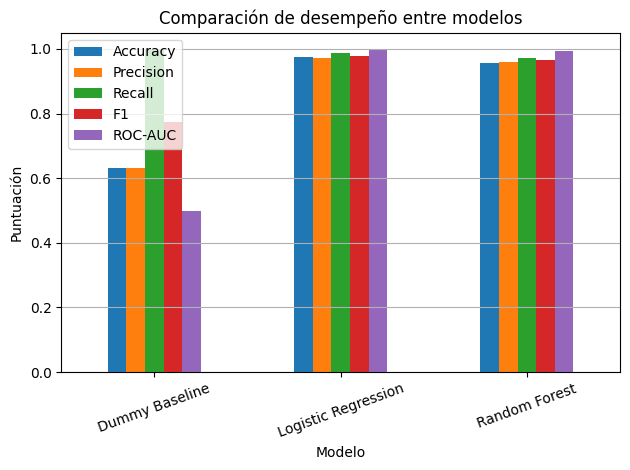

In [ ]:
#celda 17

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

results_plot = results_df.set_index("Modelo")[metrics]

plt.figure(figsize=(10,6))
results_plot.plot(kind="bar")
plt.title("Comparación de desempeño entre modelos")
plt.ylabel("Puntuación")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

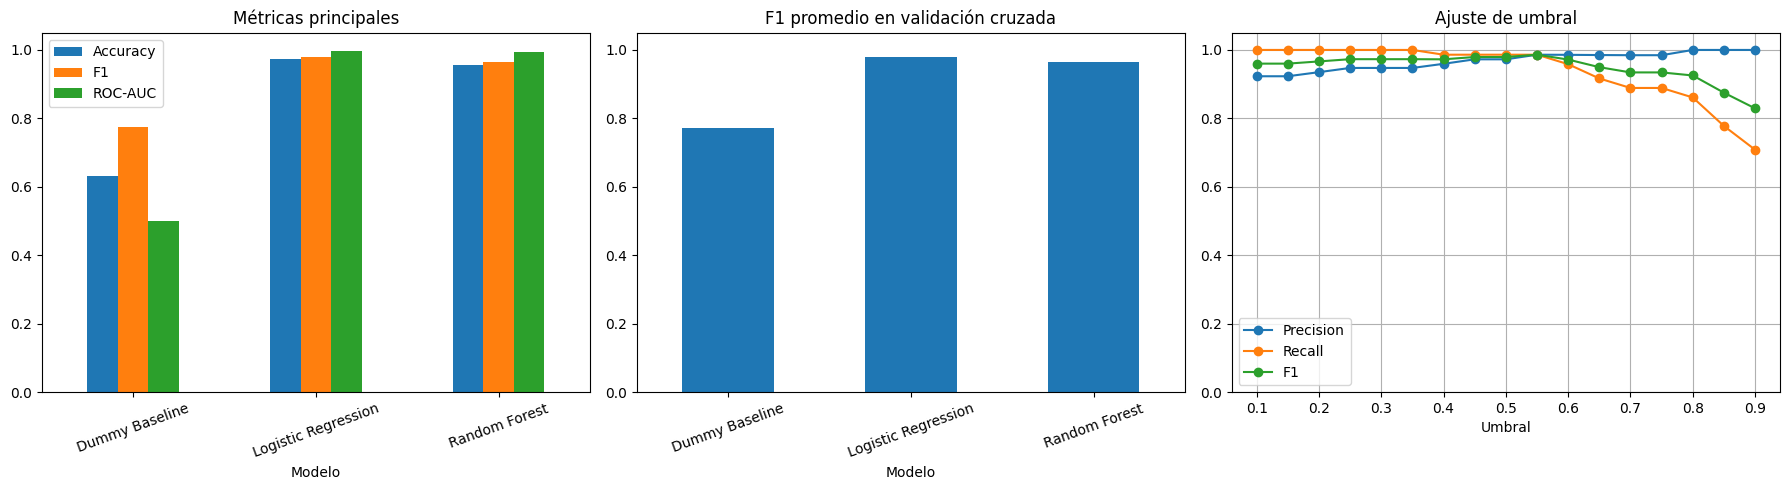

In [ ]:
#celda 18

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Métricas principales
results_df.set_index("Modelo")[["Accuracy", "F1", "ROC-AUC"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Métricas principales")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=20)

# Gráfica 2: Validación cruzada
cv_df.set_index("Modelo")["F1 promedio CV"].plot(kind="bar", ax=axes[1])
axes[1].set_title("F1 promedio en validación cruzada")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)

# Gráfica 3: Ajuste de umbral
axes[2].plot(threshold_df["Umbral"], threshold_df["Precision"], marker="o", label="Precision")
axes[2].plot(threshold_df["Umbral"], threshold_df["Recall"], marker="o", label="Recall")
axes[2].plot(threshold_df["Umbral"], threshold_df["F1"], marker="o", label="F1")
axes[2].set_title("Ajuste de umbral")
axes[2].set_xlabel("Umbral")
axes[2].set_ylim(0, 1.05)
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

In [ ]:
#celda 19

best_model_name = results_df.sort_values(by="F1", ascending=False).iloc[0]["Modelo"]
best_f1 = results_df.sort_values(by="F1", ascending=False).iloc[0]["F1"]
best_auc = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["ROC-AUC"]

print("Modelo seleccionado:", best_model_name)
print("F1-score:", round(best_f1, 4))
print("Mejor ROC-AUC:", round(best_auc, 4))
print("Umbral recomendado para Logistic Regression:", round(best_threshold_row["Umbral"], 2))

Modelo seleccionado: Logistic Regression
F1-score: 0.9793
Mejor ROC-AUC: 0.9957
Umbral recomendado para Logistic Regression: 0.55
